In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import tdt
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore
from math import pi
from statistics import mean
import csv
import io
import cv2
import os
import scipy.io as spio
from matplotlib.patches import ConnectionPatch
from scipy.signal import find_peaks, peak_widths,resample,correlate, correlation_lags,peak_prominences,resample,butter, lfilter, freqz,medfilt,detrend
from more_itertools import pairwise


params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)
def format_ax(ax,xlim,ylim,xspace,yspace):
   

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))


In [2]:
### Function to convert matlab struct to python dictionary, adapted from https://stackoverflow.com/questions/7008608/scipy-io-loadmat-nested-structures-i-e-dictionaries
def loadmat(filename):
    '''
    this function should be called instead of direct spio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    '''
    def _check_keys(d):
        '''
        checks if entries in dictionary are mat-objects. If yes
        todict is called to change them to nested dictionaries
        '''
        for key in d:
            if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
                d[key] = _todict(d[key])
        return d

    def _todict(matobj):
        '''
        A recursive function which constructs from matobjects nested dictionaries
        '''
        d = {}
        for strg in matobj._fieldnames:
            elem = matobj.__dict__[strg]
            if isinstance(elem, spio.matlab.mio5_params.mat_struct):
                d[strg] = _todict(elem)
            elif isinstance(elem, np.ndarray):
                d[strg] = _tolist(elem)
            else:
                d[strg] = elem
        return d

    def _tolist(ndarray):
        '''
        A recursive function which constructs lists from cellarrays
        (which are loaded as numpy ndarrays), recursing into the elements
        if they contain matobjects.
        '''
        elem_list = []
        for sub_elem in ndarray:
            if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
                elem_list.append(_todict(sub_elem))
            elif isinstance(sub_elem, np.ndarray):
                elem_list.append(_tolist(sub_elem))
            else:
                elem_list.append(sub_elem)
        return elem_list
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

In [3]:
### Functions for ellipise fitting, from https://scipython.com/blog/direct-linear-least-squares-fitting-of-an-ellipse/

def fit_ellipse(x, y):
    """

    Fit the coefficients a,b,c,d,e,f, representing an ellipse described by
    the formula F(x,y) = ax^2 + bxy + cy^2 + dx + ey + f = 0 to the provided
    arrays of data points x=[x1, x2, ..., xn] and y=[y1, y2, ..., yn].

    Based on the algorithm of Halir and Flusser, "Numerically stable direct
    least squares fitting of ellipses'.


    """

    D1 = np.vstack([x**2, x*y, y**2]).T
    D2 = np.vstack([x, y, np.ones(len(x))]).T
    S1 = D1.T @ D1
    S2 = D1.T @ D2
    S3 = D2.T @ D2
    T = -np.linalg.inv(S3) @ S2.T
    M = S1 + S2 @ T
    C = np.array(((0, 0, 2), (0, -1, 0), (2, 0, 0)), dtype=float)
    M = np.linalg.inv(C) @ M
    eigval, eigvec = np.linalg.eig(M)
    con = 4 * eigvec[0]* eigvec[2] - eigvec[1]**2
    ak = eigvec[:, np.nonzero(con > 0)[0]]
    return np.concatenate((ak, T @ ak)).ravel()




def cart_to_pol(coeffs):
    """

    Convert the cartesian conic coefficients, (a, b, c, d, e, f), to the
    ellipse parameters, where F(x, y) = ax^2 + bxy + cy^2 + dx + ey + f = 0.
    The returned parameters are x0, y0, ap, bp, e, phi, where (x0, y0) is the
    ellipse centre; (ap, bp) are the semi-major and semi-minor axes,
    respectively; e is the eccentricity; and phi is the rotation of the semi-
    major axis from the x-axis.

    """

    # We use the formulas from https://mathworld.wolfram.com/Ellipse.html
    # which assumes a cartesian form ax^2 + 2bxy + cy^2 + 2dx + 2fy + g = 0.
    # Therefore, rename and scale b, d and f appropriately.
    a = coeffs[0]
    b = coeffs[1] / 2
    c = coeffs[2]
    d = coeffs[3] / 2
    f = coeffs[4] / 2
    g = coeffs[5]

    den = b**2 - a*c
    if den > 0:
        raise ValueError('coeffs do not represent an ellipse: b^2 - 4ac must'
                         ' be negative!')

    # The location of the ellipse centre.
    x0, y0 = (c*d - b*f) / den, (a*f - b*d) / den

    num = 2 * (a*f**2 + c*d**2 + g*b**2 - 2*b*d*f - a*c*g)
    fac = np.sqrt((a - c)**2 + 4*b**2)
    # The semi-major and semi-minor axis lengths (these are not sorted).
    ap = np.sqrt(num / den / (fac - a - c))
    bp = np.sqrt(num / den / (-fac - a - c))

    # Sort the semi-major and semi-minor axis lengths but keep track of
    # the original relative magnitudes of width and height.
    width_gt_height = True
    if ap < bp:
        width_gt_height = False
        ap, bp = bp, ap

    # The eccentricity.
    r = (bp/ap)**2
    if r > 1:
        r = 1/r
    e = np.sqrt(1 - r)

    
    # The angle of anticlockwise rotation of the major-axis from x-axis.
    if b == 0:
        
        phi = 0 if a < c else np.pi/2
    else:
        phi = np.arctan((2.*b) / (a - c)) / 2
        if a > c:
            phi += np.pi/2
    if not width_gt_height:
        # Ensure that phi is the angle to rotate to the semi-major axis.
        phi += np.pi/2
    phi = phi % np.pi

    return x0, y0, ap, bp, e, phi


def get_ellipse_pts(params, npts=100, tmin=0, tmax=2*np.pi):
    """
    Return npts points on the ellipse described by the params = x0, y0, ap,
    bp, e, phi for values of the parametric variable t between tmin and tmax.

    """

    x0, y0, ap, bp, e, phi = params
    # A grid of the parametric variable, t.
    t = np.linspace(tmin, tmax, npts)
    x = x0 + ap * np.cos(t) * np.cos(phi) - bp * np.sin(t) * np.sin(phi)
    y = y0 + ap * np.cos(t) * np.sin(phi) + bp * np.sin(t) * np.cos(phi)
    return x, y




In [4]:
### Pupil class for fitting ellipses to DLC pupil points
class Pupil:
    def __init__(self,frame,lpx,lpy,lpl,ldpx,ldpy,ldpl,dpx,dpy,dpl,rdpx,rdpy,rdpl,rpx,rpy,rpl,rvpx,rvpy,rvpl,vpx,vpy,vpl,lvpx,lvpy,lvpl):
        self.frame = int(frame)   
        self.lpx = float(lpx)
        self.ldpx = float(ldpx)
        self.lvpx = float(lvpx)
        self.rpx = float(rpx)
        self.rdpx = float(rdpx)
        self.rvpx =float(rvpx)
        self.dpx = float(dpx)
        self.vpx = float(vpx)
        self.lpy = float(lpy)
        self.ldpy = float(ldpy)
        self.lvpy = float(lvpy)
        self.rpy = float(rpy)
        self.rdpy = float(rdpy)
        self.rvpy = float(rvpy)
        self.dpy = float(dpy)
        self.vpy = float(vpy)
        self.lpl = float(lpl)
        self.ldpl=float(ldpl)
        self.lvpl=float(lvpl)
        self.rpl=float(rpl)
        self.rdpl=float(rdpl )
        self.rvpl=float(rvpl)
        self.dpl=float(dpl)
        self.vpl=float(vpl)
        
    def get_img_from_fig(self,fig, dpi=256):
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=dpi,transparent = True,bbox_inches='tight')
        buf.seek(0)
        img_arr = np.frombuffer(buf.getvalue(), dtype=np.uint8)
        buf.close()
        img = cv2.imdecode(img_arr, 1)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.close(fig)

        return img

    
    def fit_ellipse(self,plot = False,frame = []):
        x = np.array([self.lpx,self.ldpx,self.lvpx,self.rpx,self.rdpx,self.rvpx,self.dpx,self.vpx])
        y = np.array([self.lpy,self.ldpy,self.lvpy,self.rpy,self.rdpy,self.rvpy,self.dpy,self.vpy])
        coeffs = fit_ellipse(x, y)
        x0, y0, ap, bp, e, phi = cart_to_pol(coeffs)


        if (plot and (len(frame) != 0)):
            fig, ax = plt.subplots(dpi = 256)
            im = frame
            ax.set_aspect('equal', adjustable='box')
            ax.imshow(im)
            ax.set_xlim(0,im.shape[1])
            ax.set_ylim(0,im.shape[0])
            X, Y = get_ellipse_pts((x0, y0, ap, bp, e, phi))
            ax.plot(X, Y,color = "white",linestyle = "dashed",linewidth = 5)
            #ax.plot(x, y, '.',markersize=5.5)

            ax.axis('off')
            plt.savefig(rf"test.pdf",format ="pdf")
            print(1)

            return self.get_img_from_fig(fig,dpi = 256)

            
        elif plot:
            fig, ax = plt.subplots()
            ax.set_aspect('equal', adjustable='box')
            ax.set_ylim(0,200)
            ax.set_xticks([0,50,100,150,200])
            ax.set_xlim(0,200)
            ax.set_yticks([0,50,100,150,200])
            ax.plot(x, y, 'x')     # given points
            x, y = get_ellipse_pts((x0, y0, ap, bp, e, phi))
            ax.plot(x, y)
            plt.show()
            return x,y
        
        return x0, y0, ap, bp
    
    def get_area(self):
        x0, y0, ap, bp = self.fit_ellipse()
        return pi * ap * bp
    def get_diameter(self):
        x0, y0, ap, bp = self.fit_ellipse()
        return ap*2
    
    def get_points(self):
        x = np.array([self.lpx,self.ldpx,self.lvpx,self.rpx,self.rdpx,self.rvpx,self.dpx,self.vpx])
        y = np.array([self.lpy,self.ldpy,self.lvpy,self.rpy,self.rdpy,self.rvpy,self.dpy,self.vpy])
        coeffs = fit_ellipse(x, y)
        x0, y0, ap, bp, e, phi = cart_to_pol(coeffs)
        X, Y = get_ellipse_pts((x0, y0, ap, bp, e, phi))
        return X,Y
    def get_coords(self):
        x = np.array([self.lpx,self.ldpx,self.lvpx,self.rpx,self.rdpx,self.rvpx,self.dpx,self.vpx])
        y = np.array([self.lpy,self.ldpy,self.lvpy,self.rpy,self.rdpy,self.rvpy,self.dpy,self.vpy])
        return x,y




  





#function that takes an input a csv row and returns a pupil object
def load_pupil(row):
    pupil = Pupil(row[0],row[1],row[2],row[3],row[4],row[5],row[6],row[7],row[8],row[9],row[10],row[11],row[12],row[13],row[14],row[15],row[16],row[17],row[18],row[19],row[20],row[21],row[22],row[23],row[24])  
    return pupil
    





In [5]:
### Function to get pupil without interpolating
def get_raw_pupil(id,date,sess = 1):
    csv_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_vid.mjpegDLC_resnet50_DLC_8points_pupilOct25shuffle1_2940000.csv"
    fps = 20
    thresh = .95
    drop_count = 0
    line_count = 0
    Areas = []

    with open(csv_path, newline='') as csvfile:
        csvreader = csv.reader(csvfile, delimiter=',')
        line_count = 0
        for row in csvreader:
            if line_count >=3:
                new_pupil = load_pupil(row)
                if (new_pupil.rpl > thresh) & (new_pupil.lpl > thresh) & (new_pupil.lvpl > thresh) & (new_pupil.rvpl > thresh) &( new_pupil.rdpl > thresh)&(new_pupil.ldpl > thresh) & (new_pupil.vpl > thresh) & (new_pupil.dpl > thresh):
                    area = new_pupil.get_area()
                    Areas.append(float(area))
                else:
                    Areas.append(np.nan)
            line_count +=1
    return zscore(Areas,nan_policy = "omit")

In [6]:
### Function to get dFF from TDT data for session, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#importing-the-data

def get_tone_dff(id,date):
    path = rf"{base_dir}/{id}/{date}"
    for filename in os.listdir(path):
        if os.path.isdir(os.path.join(path, filename)):
            blockpath = (os.path.join(path, filename))
    data = tdt.read_block(blockpath)
    GCAMP = '_465A' # GCaMP channel
    ISOS = '_405A' # Isosbestic channel
    TONE = 'PC2_'
    stamps = 'PC0_'
    time = np.linspace(1,len(data.streams[GCAMP].data), len(data.streams[GCAMP].data))/data.streams[GCAMP].fs
    N = 10 # Average every 10 samples into 1 value
    F405 = []
    F465 = []

    for i in range(0, len(data.streams[GCAMP].data), N):
        F465.append(np.mean(data.streams[GCAMP].data[i:i+N-1])) # This is the moving window mean
    data.streams[GCAMP].data = F465

    for i in range(0, len(data.streams[ISOS].data), N):
        F405.append(np.mean(data.streams[ISOS].data[i:i+N-1]))
    data.streams[ISOS].data = F405

    #decimate time array to match length of demodulated stream
    time = time[::N] # go from beginning to end of array in steps on N
    time = time[:len(data.streams[GCAMP].data)]


    # Detrending and dFF
    # Full trace dFF according to Lerner et al. 2015
    # http://dx.doi.org/10.1016/j.cell.2015.07.014
    # dFF using 405 fit as baseline

    x = np.array(data.streams[ISOS].data)
    y = np.array(data.streams[GCAMP].data)
    bls = np.polyfit(x, y, 1)
    Y_fit_all = np.multiply(bls[0], x) + bls[1]
    Y_dF_all = y - Y_fit_all

    dFF = zscore(np.multiply(100, np.divide(Y_dF_all, Y_fit_all)))
    return dFF,time

In [7]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [8]:
### Function to align data to tones

def get_pupil_tone(id,date,sess = 1,pupil = True,face = True):
    
    mat_path = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
    Data = loadmat(mat_path)["data"]["response"]
    freqs = Data["trial_freq"]
    intensity = Data["trial_dB"]

    if pupil:
        areas = get_raw_pupil(id,date)

    path = rf"{base_dir}/{id}/{date}"
    for filename in os.listdir(path):
        if os.path.isdir(os.path.join(path, filename)):
            blockpath = (os.path.join(path, filename))
    data = tdt.read_block(blockpath)
    GCAMP = '_465A' # GCaMP channel
    ISOS = '_405A' # Isosbestic channel
    TONE = 'PC2_'
    stamps = 'PC0_'
    time = np.linspace(1,len(data.streams[GCAMP].data), len(data.streams[GCAMP].data))/data.streams[GCAMP].fs
    N = 10 # Average every 10 samples into 1 value
    F405 = []
    F465 = []

    for i in range(0, len(data.streams[GCAMP].data), N):
        F465.append(np.mean(data.streams[GCAMP].data[i:i+N-1])) # This is the moving window mean
    data.streams[GCAMP].data = F465

    for i in range(0, len(data.streams[ISOS].data), N):
        F405.append(np.mean(data.streams[ISOS].data[i:i+N-1]))
    data.streams[ISOS].data = F405

    #decimate time array to match length of demodulated stream
    time = time[::N] # go from beginning to end of array in steps on N
    time = time[:len(data.streams[GCAMP].data)]


    # Detrending and dFF
    # Full trace dFF according to Lerner et al. 2015
    # http://dx.doi.org/10.1016/j.cell.2015.07.014
    # dFF using 405 fit as baseline

    x = np.array(data.streams[ISOS].data)
    y = np.array(data.streams[GCAMP].data)
    bls = np.polyfit(x, y, 1)
    Y_fit_all = np.multiply(bls[0], x) + bls[1]
    Y_dF_all = y - Y_fit_all

    dFF = zscore(np.multiply(100, np.divide(Y_dF_all, Y_fit_all)))
    std_dFF = np.std(dFF)

    if len(data.epocs[TONE].onset) > 100:
        data.epocs[TONE].onset = data.epocs[TONE].onset[:100]


           
    trial_matrix,peri_times = trial_align(data.epocs[TONE].onset,time,dFF,fps = data.streams[GCAMP].fs/N,pre = 10, post = 10)
    x = np.arange(0,data.epocs[stamps].onset[-1],0.05)
    xp = data.epocs[stamps].onset[:-1]
    fp = areas[:len(data.epocs[stamps].onset)]
    areas = np.interp(x,xp,fp)

    pupil_matrix,pupil_peri = trial_align(data.epocs[TONE].onset,x,areas,fps =20 ,pre = 10, post = 10)


    df_list = []
    fps = data.streams[GCAMP].fs/N

    deltas = []
    good_trials = []
    for j,trial in enumerate(pupil_matrix):
        pre_tone = np.nanmean(trial[160:200])
        post_tone = np.nanmean(trial[200:270])
        deltas.append(post_tone-pre_tone)
        if post_tone-pre_tone > 0:
            good_trials.append(j)
            

    
    pre = 10
    for j,trial in enumerate(trial_matrix):
        if j in good_trials:
            baseline = np.mean(trial[int((pre-2)*fps):int((pre)*fps)])
            trial = trial - baseline
            for i,time in enumerate(peri_times):
                new_dict = {"Time from Peak (s)" : time, "trial" : j, "value" : trial[i], "type" : "dFF", "ID" : id, "Date": date,"intensity" : intensity[j],"frequency":freqs[j],"delta":deltas[j]}
                df_list.append(new_dict)    
    

    for j,trial in enumerate(pupil_matrix):
        if j in good_trials:
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(pupil_peri):
                new_dict = {"Time from Peak (s)" : time, "trial" : j, "value" : trial[i], "type" : "Pupil", "ID" : id, "Date": date,"intensity" : intensity[j],"frequency":freqs[j],'delta':deltas[j]}
                df_list.append(new_dict)

   
    aligned_df = pd.DataFrame.from_dict(df_list)
    labels = ["1","2","3","4"]
    aligned_df["bin"] = pd.qcut(aligned_df["delta"],4,labels = labels)

    return aligned_df

In [9]:
### Function to get metrics for tone sessions

def get_tone_metrics(id,date,sess = 1,pupil = True,face = True):
    
    mat_path = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
    Data = loadmat(mat_path)["data"]["response"]
    freqs = Data["trial_freq"]
    intensity = Data["trial_dB"]

    if pupil:
        areas = get_raw_pupil(id,date)

    path = rf"{base_dir}/{id}/{date}"
    for filename in os.listdir(path):
        if os.path.isdir(os.path.join(path, filename)):
            blockpath = (os.path.join(path, filename))
    data = tdt.read_block(blockpath)
    GCAMP = '_465A' # GCaMP channel
    ISOS = '_405A' # Isosbestic channel
    TONE = 'PC2_'
    stamps = 'PC0_'
    time = np.linspace(1,len(data.streams[GCAMP].data), len(data.streams[GCAMP].data))/data.streams[GCAMP].fs
    N = 10 # Average every 10 samples into 1 value
    F405 = []
    F465 = []

    for i in range(0, len(data.streams[GCAMP].data), N):
        F465.append(np.mean(data.streams[GCAMP].data[i:i+N-1])) # This is the moving window mean
    data.streams[GCAMP].data = F465

    for i in range(0, len(data.streams[ISOS].data), N):
        F405.append(np.mean(data.streams[ISOS].data[i:i+N-1]))
    data.streams[ISOS].data = F405

    #decimate time array to match length of demodulated stream
    time = time[::N] # go from beginning to end of array in steps on N
    time = time[:len(data.streams[GCAMP].data)]


    # Detrending and dFF
    # Full trace dFF according to Lerner et al. 2015
    # http://dx.doi.org/10.1016/j.cell.2015.07.014
    # dFF using 405 fit as baseline

    x = np.array(data.streams[ISOS].data)
    y = np.array(data.streams[GCAMP].data)
    bls = np.polyfit(x, y, 1)
    Y_fit_all = np.multiply(bls[0], x) + bls[1]
    Y_dF_all = y - Y_fit_all

    dFF = zscore(np.multiply(100, np.divide(Y_dF_all, Y_fit_all)))
    std_dFF = np.std(dFF)

    if len(data.epocs[TONE].onset) > 100:
        data.epocs[TONE].onset = data.epocs[TONE].onset[:100]


           
    trial_matrix,peri_times = trial_align(data.epocs[TONE].onset,time,dFF,fps = data.streams[GCAMP].fs/N,pre = 10, post = 10)
    x = np.arange(0,data.epocs[stamps].onset[-1],0.05)
    xp = data.epocs[stamps].onset[:-1]
    fp = areas[:len(data.epocs[stamps].onset)]
    areas = np.interp(x,xp,fp)

    pupil_matrix,pupil_peri = trial_align(data.epocs[TONE].onset,x,areas,fps =20 ,pre = 10, post = 10)


    df_list = []
    fps = data.streams[GCAMP].fs/N

    deltas = []
    good_trials = []
    for j,trial in enumerate(pupil_matrix):
        pre_tone = np.nanmean(trial[160:200])
        post_tone = np.nanmean(trial[200:270])
        deltas.append(post_tone-pre_tone)

        if post_tone-pre_tone>0:
            good_trials.append(j)
            

    
    pre = 10
    for j,trial in enumerate(trial_matrix):
        if j in good_trials:
            pre_tone = np.mean(trial[int((pre-2)*fps):int((pre)*fps)])
            post_tone = np.mean(trial[int((pre)*fps):int((pre+3.5)*fps)])
            new_dict = {"trial" : j, "dFF" : post_tone - pre_tone, "Pupil" : deltas[j], "ID" : id, "Date": date,"intensity" : intensity[j],"frequency":str(freqs[j]/1000)}
            df_list.append(new_dict)    

    aligned_df = pd.DataFrame.from_dict(df_list)
    labels = ["1","2","3","4"]
    aligned_df["bin"] = pd.qcut(aligned_df["Pupil"],4,labels = labels)

    return aligned_df


In [10]:
### Helper functions for detrending

def AUC_rightMethod(xs, ys):
    area = 0
    for (ax, ay), (bx, by) in pairwise(zip(xs, ys)):
        h = bx - ax
        area += h*by
    return area

def AUC_trapezoidMethod(xs, ys):
    area = 0
    for (ax, ay), (bx, by) in pairwise(zip(xs, ys)):
        h = bx - ax
        area += h*(ay + by)/2
    return area

In [11]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [12]:
### Get data for Fig6B, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#importing-the-data

id = "004114"
date = "20230922"
sess = 1
areas = get_raw_pupil(id,date)

mat_path = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
Data = loadmat(mat_path)["data"]["response"]
freqs = Data["trial_freq"]
intensity = Data["trial_dB"]

path = rf"{base_dir}/{id}/{date}"
for filename in os.listdir(path):
    if os.path.isdir(os.path.join(path, filename)):
        blockpath = (os.path.join(path, filename))
data = tdt.read_block(blockpath)
GCAMP = '_465A' # GCaMP channel
ISOS = '_405A' # Isosbestic channel
TONE = 'PC2_'
stamps = 'PC0_'
time = np.linspace(1,len(data.streams[GCAMP].data), len(data.streams[GCAMP].data))/data.streams[GCAMP].fs
N = 10
F405 = []
F465 = []

for i in range(0, len(data.streams[GCAMP].data), N):
    F465.append(np.mean(data.streams[GCAMP].data[i:i+N-1]))
data.streams[GCAMP].data = F465

for i in range(0, len(data.streams[ISOS].data), N):
    F405.append(np.mean(data.streams[ISOS].data[i:i+N-1]))
data.streams[ISOS].data = F405

time = time[::N]
time = time[:len(data.streams[GCAMP].data)]

x = np.array(data.streams[ISOS].data)
y = np.array(data.streams[GCAMP].data)
bls = np.polyfit(x, y, 1)
Y_fit_all = np.multiply(bls[0], x) + bls[1]
Y_dF_all = y - Y_fit_all

dFF = zscore(np.multiply(100, np.divide(Y_dF_all, Y_fit_all)))

x = np.arange(0,data.epocs[stamps].onset[-1],0.05)
xp = data.epocs[stamps].onset[:-1]
fp = areas[:len(data.epocs[stamps].onset)]
areas = np.interp(x,xp,fp)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:34: RuntimeWarning: invalid value encountered in cast
  sample = 

Found Synapse note file: /Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata/004114/20230922/004114-230922-160233/Notes.txt
read from t=0s to t=1809.86s


/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3508: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


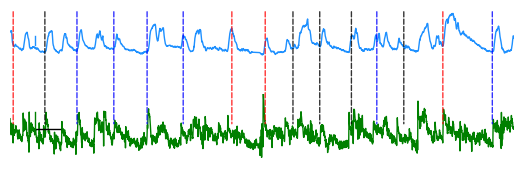

In [13]:
### Plot Fig6B

fig,(ax1,ax2) = plt.subplots(2,figsize = (6.5,2))

ax1.plot(x,areas,color = "dodgerblue",linewidth = 1)
ax2.plot(time,dFF,color = "green",linewidth = 1)
x_start = 700
x_end = 900
x_space = 5
ylim = [-4,4]


for i,freq in enumerate(freqs):
    if (data.epocs[TONE].onset[i] > x_start) and (data.epocs[TONE].onset[i] < x_end):
        xyA = (data.epocs[TONE].onset[i],3.8)
        xyB = (data.epocs[TONE].onset[i],0.3)
        if freq == 7000:
            con = ConnectionPatch(xyA=xyA, coordsA=ax1.transData,xyB=xyB, coordsB=ax2.transData,color = "black",alpha = 0.8,linestyle = "dashed",linewidth = 1)
            fig.add_artist(con)

        if freq == 8000:
            con = ConnectionPatch(xyA=xyA, coordsA=ax1.transData,xyB=xyB, coordsB=ax2.transData,color = "blue",alpha = 0.8,linestyle = "dashed",linewidth = 1)
            fig.add_artist(con)

        if freq == 9000:
            con = ConnectionPatch(xyA=xyA, coordsA=ax1.transData,xyB=xyB, coordsB=ax2.transData,color = "red",alpha = 0.8,linestyle = "dashed",linewidth = 1)
            fig.add_artist(con)


for ax in [ax1,ax2]:
    ax.set_xlim(x_start,x_end)
    ax.set_xticks(np.arange(x_start,x_end + x_space,x_space))
    ax.set_ylim(ylim)
ax2.set_ylim(-2,2)

ax1.spines[['bottom']].set_visible(False)
ax1.spines[['left']].set_visible(False)

ax1.get_xaxis().set_visible(False)
ax1.get_yaxis().set_visible(False)

ax2.spines[['bottom']].set_visible(False)
ax2.spines[['left']].set_visible(False)

ax2.get_xaxis().set_visible(False)
ax2.get_yaxis().set_visible(False)

ax2.plot([710,720], [0, 0],color = "black",linewidth = 1)

ax1.plot([710,710], [0, 1],color = "dodgerblue",linewidth = 1)
ax2.plot([710,710], [0, 1],color = "green",linewidth = 1)


In [14]:
### Get data for Fig6C, 6F, 6G
id_date = {
"004113":["20230922"],
"004114":["20230922"],
"004115":["20230922"],
"004116":["20230922"],
"004117":["20230922"],
"004118":["20230922"],
}

dfs = []
for id,dates in id_date.items():
    for date in dates:
        dfs.append(get_pupil_tone(id,date))
df = pd.concat(dfs)
tone_df = df.reset_index()

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


Found Synapse note file: /Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata/004113/20230922/004113-230922-152158/Notes.txt
read from t=0s to t=2097.27s


/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:1429: Warning: PC   buddy epoc not found, skipping
  warnings.warn(epocs.buddies[ii] + ' buddy epoc not found, skipping', Warning)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/432722368.py:14: RankWarning: Polyfit may be poorly conditioned
  dfs.append(get_pupil_tone(id,date))
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipyk

Found Synapse note file: /Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata/004114/20230922/004114-230922-160233/Notes.txt
read from t=0s to t=1809.86s


/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:34: RuntimeWarning: invalid value encountered in cast
  sample = np.uint64(sample)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/432722368.py:14: RankWarning: Polyfit may be poorly conditioned
  dfs.append(get_pupil_tone(id,date))
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning:

...

/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:34: RuntimeWarning: invalid value encountered in cast
  sample = np.uint64(sample)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/432722368.py:14: RankWarning: Polyfit may be poorly conditioned
  dfs.append(get_pupil_tone(id,date))
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning:

Found Synapse note file: /Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata/004117/20230922/004117-230922-174503/Notes.txt
read from t=0s to t=1838.04s


/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:34: RuntimeWarning: invalid value encountered in cast
  sample = np.uint64(sample)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/432722368.py:14: RankWarning: Polyfit may be poorly conditioned
  dfs.append(get_pupil_tone(id,date))
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning:

Found Synapse note file: /Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata/004118/20230922/004118-230922-182315/Notes.txt
read from t=0s to t=1813.05s


/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:34: RuntimeWarning: invalid value encountered in cast
  sample = np.uint64(sample)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/432722368.py:14: RankWarning: Polyfit may be poorly conditioned
  dfs.append(get_pupil_tone(id,date))


In [15]:
### Get data for Fig6D, 6E

id_date = {
"004113":["20230922"],
"004114":["20230922"],
"004115":["20230922"],
"004116":["20230922"],
"004117":["20230922"],
"004118":["20230922"],
}

dfs = []
for id,dates in id_date.items():
    for date in dates:
        dfs.append(get_tone_metrics(id,date))
df = pd.concat(dfs)
bar_df = df.reset_index()

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


Found Synapse note file: /Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata/004113/20230922/004113-230922-152158/Notes.txt
read from t=0s to t=2097.27s


/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:1429: Warning: PC   buddy epoc not found, skipping
  warnings.warn(epocs.buddies[ii] + ' buddy epoc not found, skipping', Warning)
/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:34: RuntimeWarning: invalid value encountered in cast
  sample = np.uint64(sample)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/94835674.py:15: RankWarning: Polyfit may be poorly conditioned
  dfs.append(get_tone_metrics(id,date))
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the 

Found Synapse note file: /Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata/004114/20230922/004114-230922-160233/Notes.txt
read from t=0s to t=1809.86s


/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:34: RuntimeWarning: invalid value encountered in cast
  sample = np.uint64(sample)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/94835674.py:15: RankWarning: Polyfit may be poorly conditioned
  dfs.append(get_tone_metrics(id,date))
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning

...

/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:34: RuntimeWarning: invalid value encountered in cast
  sample = np.uint64(sample)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/94835674.py:15: RankWarning: Polyfit may be poorly conditioned
  dfs.append(get_tone_metrics(id,date))
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning

Found Synapse note file: /Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata/004117/20230922/004117-230922-174503/Notes.txt
read from t=0s to t=1838.04s


/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:34: RuntimeWarning: invalid value encountered in cast
  sample = np.uint64(sample)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/94835674.py:15: RankWarning: Polyfit may be poorly conditioned
  dfs.append(get_tone_metrics(id,date))
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning

Found Synapse note file: /Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata/004118/20230922/004118-230922-182315/Notes.txt
read from t=0s to t=1813.05s


/Users/nithik/anaconda3/envs/HudaLab/lib/python3.10/site-packages/tdt/TDTbin2py.py:34: RuntimeWarning: invalid value encountered in cast
  sample = np.uint64(sample)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/94835674.py:15: RankWarning: Polyfit may be poorly conditioned
  dfs.append(get_tone_metrics(id,date))


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/1210174964.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = tone_df.groupby(["ID","Time from Peak (s)","type","frequency","bin"]).mean().reset_index(), x = "Time from Peak (s)", y = "value",errorbar = "se",palette = ["dodgerblue","green"],linewidth = 1,hue = "type",legend = None)


Text(0, 0.5, 'Z-Score')

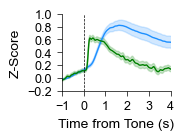

In [16]:
### Plot Fig6C
plt.figure(figsize = (1.4,1))
ax = sns.lineplot(data = tone_df.groupby(["ID","Time from Peak (s)","type","frequency","bin"]).mean().reset_index(), x = "Time from Peak (s)", y = "value",errorbar = "se",palette = ["dodgerblue","green"],linewidth = 1,hue = "type",legend = None)
format_ax(ax,[-1,4],[-0.2,1],1,0.2)
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
ax.set_xlabel("Time from Tone (s)")
ax.set_ylabel("Z-Score")

[Text(0.0, 0, '0.00'),
 Text(0.25, 0, '0.25'),
 Text(0.5, 0, '0.50'),
 Text(0.75, 0, '0.75'),
 Text(1.0, 0, '1.00'),
 Text(1.25, 0, '1.25'),
 Text(1.5, 0, '1.50'),
 Text(1.75, 0, '1.75'),
 Text(2.0, 0, '2.00'),
 Text(2.25, 0, '2.25'),
 Text(2.5, 0, '2.50'),
 Text(2.75, 0, '2+')]

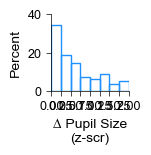

In [17]:
### Plot Fig6D

plt.figure(figsize = (1,1))
deltas = bar_df["Pupil"]
deltas = np.clip(deltas,a_max = 2,a_min = 0)
g = sns.histplot(data = deltas,bins =[0,0.25,0.5,0.75,1,1.25,1.5,1.75,2],stat = "percent",fill =False,color = "dodgerblue",linewidth = 1)
g.set_xlabel("∆ Pupil Size\n(z-scr)")
g.set_xticks(np.arange(0,3,0.25))
g.set(xlim=(0,2))
g.set_yticks(np.arange(0,80,20))
g.set(ylim=(0,40))
labels = [item.get_text() for item in plt.gca().get_xticklabels()]
labels[-1] = '2+'
plt.gca().set_xticklabels(labels)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/3745739849.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.pointplot(data = bar_df.groupby(["ID",'bin']).mean().reset_index(), x = "bin", y = "dFF",errorbar = "se",scale = 0.5,errwidth= 1.2,color = "black")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/3745739849.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = bar_df.groupby(["ID",'bin']).mean().reset_index(), x = "bin", y = "dFF",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)


[(0.0, 1.0)]

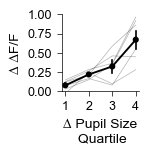

In [18]:
### Plot Fig6E
plt.figure(figsize = (1,1))
g = sns.pointplot(data = bar_df.groupby(["ID",'bin']).mean().reset_index(), x = "bin", y = "dFF",errorbar = "se",scale = 0.5,errwidth= 1.2,color = "black")
sns.lineplot(data = bar_df.groupby(["ID",'bin']).mean().reset_index(), x = "bin", y = "dFF",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.set_xlabel("∆ Pupil Size\n Quartile")
g.set_ylabel("∆ ∆F/F")
g.set_yticks(np.arange(0,1.25,0.25))
g.set(ylim=(0,1))


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/1168087406.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = tone_df.query("bin == '1'").groupby(["ID","Time from Peak (s)","type","frequency","bin"]).mean().reset_index(), x = "Time from Peak (s)", y = "value",errorbar = "se",palette = ["dodgerblue","green"],linewidth = 1,hue = "type",legend = None)


Text(0, 0.5, 'Z-Score')

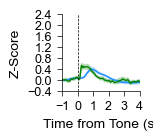

In [19]:
### Plot Fig6F
plt.figure(figsize = (1,1))
ax = sns.lineplot(data = tone_df.query("bin == '1'").groupby(["ID","Time from Peak (s)","type","frequency","bin"]).mean().reset_index(), x = "Time from Peak (s)", y = "value",errorbar = "se",palette = ["dodgerblue","green"],linewidth = 1,hue = "type",legend = None)
format_ax(ax,[-1,4],[-0.4,2.4 ],1,0.4)
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
ax.set_xlabel("Time from Tone (s)")
ax.set_ylabel("Z-Score")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/2557685800.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = tone_df.query("bin == '4'").groupby(["ID","Time from Peak (s)","type","frequency","bin"]).mean().reset_index(), x = "Time from Peak (s)", y = "value",errorbar = "se",palette = ["dodgerblue","green"],linewidth = 1,hue = "type",legend = None)


Text(0, 0.5, 'Z-Score')

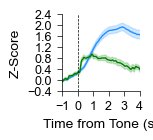

In [20]:
### Plot Fig6G
plt.figure(figsize = (1,1))
ax = sns.lineplot(data = tone_df.query("bin == '4'").groupby(["ID","Time from Peak (s)","type","frequency","bin"]).mean().reset_index(), x = "Time from Peak (s)", y = "value",errorbar = "se",palette = ["dodgerblue","green"],linewidth = 1,hue = "type",legend = None)
format_ax(ax,[-1,4],[-0.4,2.4],1,0.4)
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
ax.set_xlabel("Time from Tone (s)")
ax.set_ylabel("Z-Score")

In [21]:
### Get data for Fig6I (Left)
id_date = {   
            "004072" : ["20230801","20230803","20230804"],
            "004075" : ["20230801","20230803","20230804"],
            "004073" : ["20230803","20230804"],
            "004109" : ["20230831","20230905"],
            "004110" : ["20230905"],
            "004111" : ["20230831","20230905"],
            "004112" : ["20230831","20230905"],   
}

sess =1
pre = 10
post = 10
df_list = []
for id,dates in id_date.items():
    for date in dates:
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        tone_times = mat_data["response"]["tone_time"]
        data = mat_data["response"]["sessdata"]
        trial_types = mat_data["response"]["trial_type"]
        trial_freqs = mat_data["response"]["trial_freq"]
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        pupil_snips,pupil_peri_times = trial_align(tone_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            for i,time in enumerate(pupil_peri_times):
                new_dict = {"Time from Tone (s)" : time, "trial" : j, "value" : trial[i],"type" : "pupil", "ID" : id, "date" : date,"sess":sess,"condition":trial_types[j],"freq":trial_freqs[j]}
                df_list.append(new_dict)
vgat_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.mat

In [22]:
### Get data for Fig6I (Right)
id_date = {   
            "004072" : ["20230801","20230803","20230804"],
            "004075" : ["20230801","20230803","20230804"],
            "004073" : ["20230803","20230804"],
            "004109" : ["20230831","20230905"],
            "004110" : ["20230905"],
            "004111" : ["20230831","20230905"],
            "004112" : ["20230831","20230905"],   
}

sess =1
pre = 10
post = 10
df_list = []
for id,dates in id_date.items():
    for date in dates:
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        tone_times = mat_data["response"]["tone_time"]

        data = mat_data["response"]["sessdata"]
        trial_types = mat_data["response"]["trial_type"]
        trial_freqs = mat_data["response"]["trial_freq"]
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        pupil_snips,pupil_peri_times = trial_align(tone_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[60:100])
            post_laser = np.nanmean(trial[100:300])
        
            new_dict = {"trial" : j, "Delta" : post_laser - pre_laser,"type" : "pupil", "ID" : id, "date" : date,"sess":sess,"condition":trial_types[j],"freq":trial_freqs[j]}
            df_list.append(new_dict)
vgat_bar_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.mat

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/1624480634.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = vgat_df.groupby(["ID","Time from Tone (s)","type","condition"]).mean().reset_index(), x = "Time from Tone (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1,hue = "condition",legend = None,palette = ["black","dodgerblue"])


Text(0, 0.5, 'Pupil Size (z-scr)')

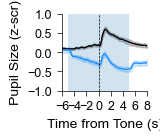

In [37]:
### Plot Fig6I (Left)

plt.figure(figsize = (1.1,1))
ax = sns.lineplot(data = vgat_df.groupby(["ID","Time from Tone (s)","type","condition"]).mean().reset_index(), x = "Time from Tone (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1,hue = "condition",legend = None,palette = ["black","dodgerblue"])
ax.axvspan(-5,5,alpha = 0.2)
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,[-6,8],[-1,1],2,0.5)
ax.set_xlabel("Time from Tone (s)")
ax.set_ylabel("Pupil Size (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/430411548.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = vgat_bar_df.groupby(["ID",'condition']).mean().reset_index(), x = "condition", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/430411548.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = vgat_bar_df.groupby(["ID",'condition']).mean().reset_index(), x = "condition", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth =

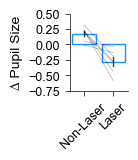

In [36]:
### Plot Fig6I (Right)

plt.figure(figsize = (0.75,1))
g = sns.barplot(data = vgat_bar_df.groupby(["ID",'condition']).mean().reset_index(), x = "condition", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
sns.lineplot(data = vgat_bar_df.groupby(["ID",'condition']).mean().reset_index(), x = "condition", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.set_ylabel("∆ Pupil Size")
g.set_yticks(np.arange(-1,0.75,0.25))
g.set(ylim=(-0.75,0.5))
g.set_xticklabels(["Non-Laser","Laser"])
g.xaxis.label.set_visible(False)
g.tick_params(axis='x', labelrotation=45)


In [32]:
### Get data for Fig6J
test_df = vgat_df.groupby(["ID","Time from Tone (s)","type","condition","date"]).mean().reset_index()
df_list = []
bar_df_list = []
for mouse in test_df.ID.unique():
    for sess_date in test_df.query(f"ID =='{mouse}'").date.unique():
        non_laser_df = test_df.query(f"ID =='{mouse}'").query(f"date =='{sess_date}'")
        non_laser_df = non_laser_df[non_laser_df["condition"] == 0]
        non_laser_y = non_laser_df["value"].to_list()[99:400]
        time = non_laser_df["Time from Tone (s)"].to_list()[99:400]
        detrended_non_laser = detrend(non_laser_y, type = 'linear')
        pre_laserAverage = np.nanmean(detrended_non_laser[60:100])
        post_laserAverage = np.nanmean(detrended_non_laser[101:141])
        delta = post_laserAverage - pre_laserAverage
        bar_new_dict = {"Delta" : delta,"type" : "pupil", "ID" : mouse, "date" : sess_date,"condition":"Non-laser"}
        bar_df_list.append(bar_new_dict)



        for x,y in zip(time,detrended_non_laser):
            new_dict = {"Time from Tone (s)" : x,"value" : y,"type" : "pupil", "ID" : mouse, "date" : sess_date,"condition":"Non-laser"}
            df_list.append(new_dict)

        laser_df = test_df.query(f"ID =='{mouse}'").query(f"date =='{sess_date}'")
        laser_df = laser_df[laser_df["condition"] == 1]
        laser_y = laser_df["value"].to_list()[99:400]
        time = laser_df["Time from Tone (s)"].to_list()[99:400]
        detrended_laser = detrend(laser_y, type = 'linear')
        pre_laserAverage = np.nanmean(detrended_laser[60:100])
        post_laserAverage = np.nanmean(detrended_laser[101:141])
        delta = post_laserAverage - pre_laserAverage
        bar_new_dict = {"Delta" : delta,"type" : "pupil", "ID" : mouse, "date" : sess_date,"condition":"Laser"}
        bar_df_list.append(bar_new_dict)



        for x,y in zip(time,detrended_laser):
            new_dict = {"Time from Tone (s)" : x,"value" : y,"type" : "pupil", "ID" : mouse, "date" : sess_date,"condition":"Laser"}
            df_list.append(new_dict)


detrend_df = pd.DataFrame.from_dict(df_list)
detrend_bar_df = pd.DataFrame.from_dict(bar_df_list)

Text(0, 0.5, 'Pupil size (z-scr)')

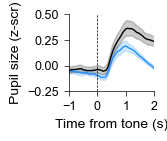

In [33]:
### Plot Fig 6J (Left)

plt.figure(figsize = (1.1,1))
ax = sns.lineplot(data = detrend_df.groupby(["ID","Time from Tone (s)","condition"]).mean(numeric_only=True).reset_index(), x = "Time from Tone (s)", y = "value",linewidth = 1,hue = "condition",palette = ["dodgerblue","black"],legend = None,errorbar="se")
format_ax(ax,[-1,2],[-0.25,0.5],1,0.25)
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
ax.set_xlabel("Time from tone (s)")
ax.set_ylabel("Pupil size (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/1626070767.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = detrend_bar_df.groupby(["ID",'condition']).mean().reset_index(), x = "condition", y = "Delta", hue = None, fill = None,errwidth= 1,edgecolor = "dodgerblue",errorbar="se",order = ["Non-laser", "Laser"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_32498/1626070767.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = detrend_bar_df.groupby(["ID",'condition']).mean().reset_index(), x = "condition", y = "Delta",units = "ID",estima

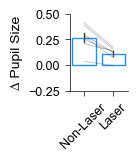

In [35]:
### Panel J bar graph

plt.figure(figsize = (0.75,1))
g = sns.barplot(data = detrend_bar_df.groupby(["ID",'condition']).mean().reset_index(), x = "condition", y = "Delta", hue = None, fill = None,errwidth= 1,edgecolor = "dodgerblue",errorbar="se",order = ["Non-laser", "Laser"])
sns.lineplot(data = detrend_bar_df.groupby(["ID",'condition']).mean().reset_index(), x = "condition", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_ylabel("∆ Pupil Size")
g.set_yticks(np.arange(-1,0.75,0.25))
g.set(ylim=(-0.25,0.5))
g.set_xticklabels(["Non-Laser","Laser"])
g.xaxis.label.set_visible(False)
g.tick_params(axis='x', labelrotation=45)